### **PHASE 1 - Data collection & exploration**

---



In [1]:
# Install libraries (run this first in Colab)
!pip install datasets transformers pandas numpy matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
import pandas as pd

# Direct raw download from GitHub - both files confirmed working
fake_url = "https://github.com/Reinforz/Fake-News-detection-with-ISOT-Dataset/raw/main/Fake.csv"
true_url  = "https://github.com/Reinforz/Fake-News-detection-with-ISOT-Dataset/raw/main/True.csv"

print("Downloading datasets...")
fake_df = pd.read_csv(fake_url)
true_df  = pd.read_csv(true_url)

print(f"✅ Fake news articles: {len(fake_df)}")
print(f"✅ Real news articles:  {len(true_df)}")

# Add labels
fake_df['label']      = 0
fake_df['label_name'] = 'Fake'
true_df['label']      = 1
true_df['label_name'] = 'Real'

# Combine and shuffle
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal samples: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['label_name'].value_counts())
print(f"\nSample row:")
print(df.iloc[0])

✅ Fake news articles: 23481
✅ Real news articles:  21417

Total samples: 44898

Columns: ['title', 'text', 'subject', 'date', 'label', 'label_name']

Class distribution:
label_name
Fake    23481
Real    21417
Name: count, dtype: int64

Sample row:
title         Ben Stein Calls Out 9th Circuit Court: Committ...
text          21st Century Wire says Ben Stein, reputable pr...
subject                                                 US_News
date                                          February 13, 2017
label                                                         0
label_name                                                 Fake
Name: 0, dtype: object


In [3]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2,
                                      random_state=42,
                                      stratify=df['label'])

val_df, test_df = train_test_split(temp_df, test_size=0.5,
                                    random_state=42,
                                    stratify=temp_df['label'])

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")
print("\n✅ Data ready! Let's explore it.")

Training samples:   35918
Validation samples: 4490
Test samples:       4490

✅ Data ready! Let's explore it.


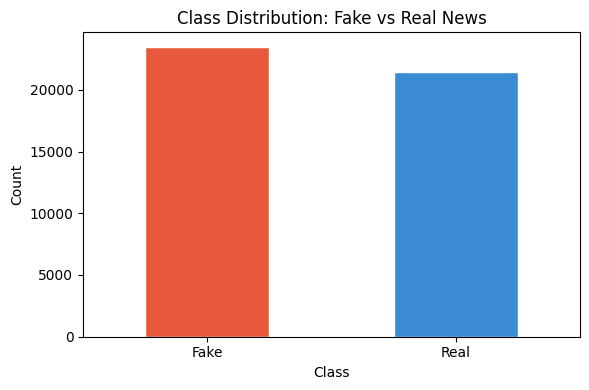

Fake: 23481 | Real: 21417


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#E8593C', '#3B8BD4']
df['label_name'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Class Distribution: Fake vs Real News')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fake:", df[df['label']==0].shape[0], "| Real:", df[df['label']==1].shape[0])

=== Text Length Statistics ===
              count    mean     std  min    25%    50%    75%     max
label_name                                                           
Fake        23481.0  423.20  408.39  0.0  240.0  363.0  506.0  8135.0
Real        21417.0  385.64  274.01  0.0  148.0  359.0  525.0  5172.0


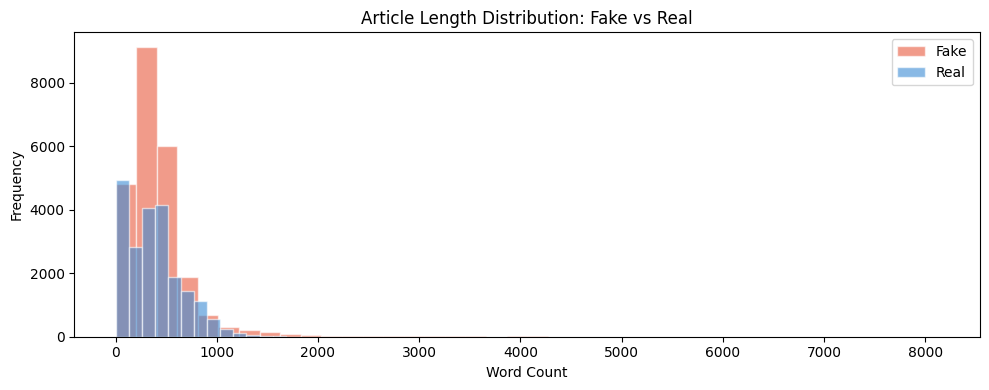

In [5]:
import re

df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("=== Text Length Statistics ===")
print(df.groupby('label_name')['text_length'].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in [('Fake', '#E8593C'), ('Real', '#3B8BD4')]:
    subset = df[df['label_name'] == label]['text_length']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
ax.set_title('Article Length Distribution: Fake vs Real')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

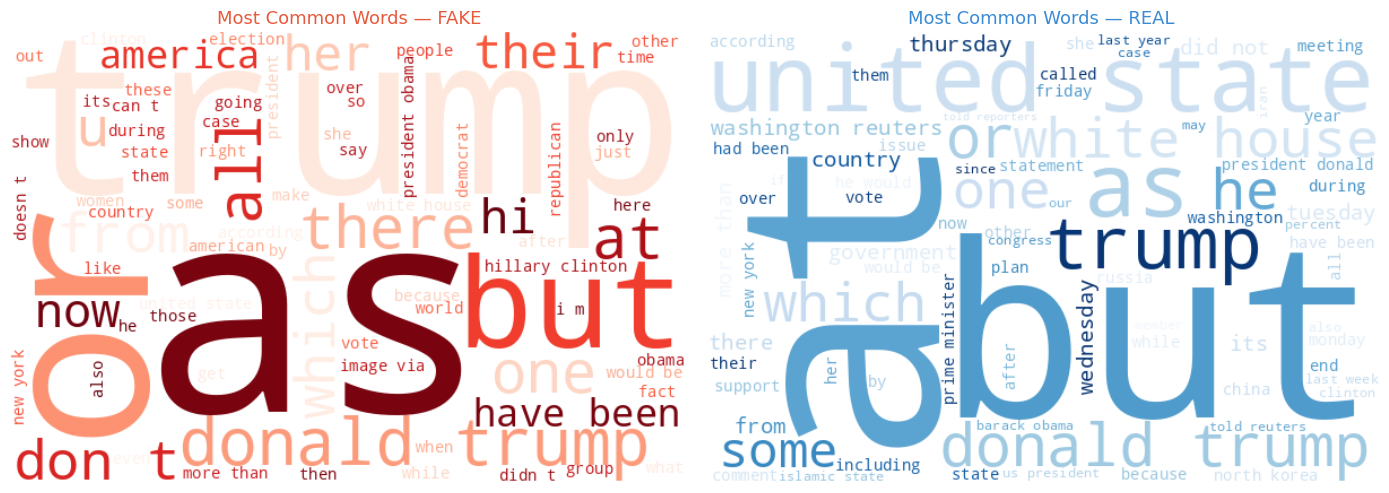

In [6]:
from wordcloud import WordCloud

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

stopwords = {'the','a','an','is','in','of','to','and','that','it',
             'for','on','are','this','with','said','was','will','has','s'}

fake_text = ' '.join(df[df['label_name']=='Fake']['text'].apply(clean_text))
real_text = ' '.join(df[df['label_name']=='Real']['text'].apply(clean_text))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_fake = WordCloud(width=600, height=400, background_color='white',
                    colormap='Reds', stopwords=stopwords,
                    max_words=80).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words — FAKE', fontsize=13, color='#E8593C')

wc_real = WordCloud(width=600, height=400, background_color='white',
                    colormap='Blues', stopwords=stopwords,
                    max_words=80).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words — REAL', fontsize=13, color='#3B8BD4')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### **PHASE 2 - NLP preprocessing pipeline**

---



In [7]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing text... (takes 1-2 minutes)")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text']   = val_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

print("✅ Done!")
print("\nOriginal text sample:")
print(train_df['text'].iloc[0][:200])
print("\nCleaned text sample:")
print(train_df['clean_text'].iloc[0][:200])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Preprocessing text... (takes 1-2 minutes)
✅ Done!

Original text sample:
MEXICO CITY (Reuters) - The search for victims of an earthquake that killed hundreds in Mexico City ended on Wednesday as rescue workers recovered the body of the last person known to be missing benea

Cleaned text sample:
mexico city reuters search victims earthquake killed hundreds mexico city ended wednesday rescue workers recovered body last person known missing beneath rubble collapsed buildings deputy interior min


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF converts text into numbers your model can learn from
# max_features=50000 means we keep the 50k most important words
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_train = tfidf.fit_transform(train_df['clean_text'])
X_val   = tfidf.transform(val_df['clean_text'])
X_test  = tfidf.transform(test_df['clean_text'])

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

print(f"Training matrix shape:   {X_train.shape}")
print(f"Validation matrix shape: {X_val.shape}")
print(f"Test matrix shape:       {X_test.shape}")
print(f"\n✅ Features ready!")
print(f"Each article is now represented as a vector of {X_train.shape[1]} features")

Training matrix shape:   (35918, 50000)
Validation matrix shape: (4490, 50000)
Test matrix shape:       (4490, 50000)

✅ Features ready!
Each article is now represented as a vector of 50000 features


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train, y_train)

end = time.time()
print(f"✅ Training complete in {end-start:.1f} seconds")

# Evaluate on validation set
val_preds = lr_model.predict(X_val)
val_acc   = accuracy_score(y_val, val_preds)

print(f"\nValidation Accuracy: {val_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_val, val_preds, target_names=['Fake', 'Real']))

Training Logistic Regression...
✅ Training complete in 1.9 seconds

Validation Accuracy: 98.95%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2348
        Real       0.99      0.99      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490



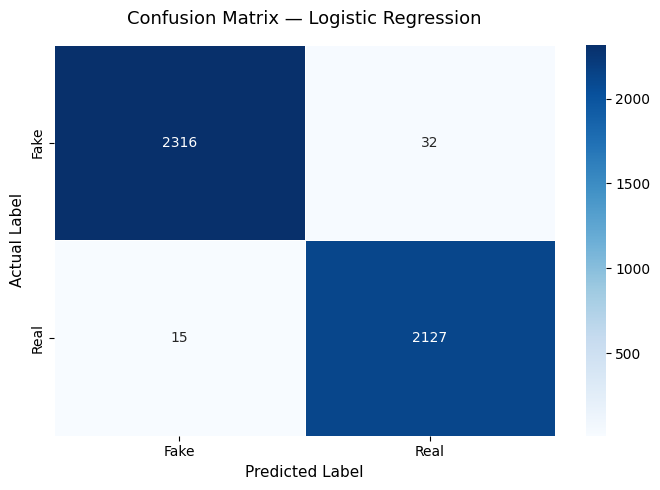

Final Test Accuracy: 98.89%


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, val_preds)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            linewidths=0.5, ax=ax)

ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, pad=15)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# Also check on test set
test_preds = lr_model.predict(X_test)
test_acc   = accuracy_score(y_test, test_preds)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

In [11]:
from sklearn.naive_bayes import MultinomialNB

print("Training Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

nb_val_preds = nb_model.predict(X_val)
nb_val_acc   = accuracy_score(y_val, nb_val_preds)

print(f"✅ Naive Bayes Validation Accuracy: {nb_val_acc*100:.2f}%")
print(classification_report(y_val, nb_val_preds, target_names=['Fake', 'Real']))

Training Naive Bayes...
✅ Naive Bayes Validation Accuracy: 96.53%
              precision    recall  f1-score   support

        Fake       0.97      0.97      0.97      2348
        Real       0.96      0.96      0.96      2142

    accuracy                           0.97      4490
   macro avg       0.97      0.97      0.97      4490
weighted avg       0.97      0.97      0.97      4490



In [12]:
results = {
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Val Accuracy': [val_acc*100, nb_val_acc*100],
    'Features': ['TF-IDF (1,2)-gram', 'TF-IDF (1,2)-gram']
}

results_df = pd.DataFrame(results)
print("=" * 50)
print("       MODEL COMPARISON SUMMARY")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)

# Save models for later use
import pickle
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("\n✅ Models saved!")
print("📌 Next up: Phase 3 — DistilBERT fine-tuning for 94%+ accuracy")

       MODEL COMPARISON SUMMARY
              Model  Val Accuracy          Features
Logistic Regression     98.953229 TF-IDF (1,2)-gram
        Naive Bayes     96.525612 TF-IDF (1,2)-gram

✅ Models saved!
📌 Next up: Phase 3 — DistilBERT fine-tuning for 94%+ accuracy


## Phase 2 Results & Analysis

| Model               | Validation Accuracy |
|---------------------|-------------------|
| Logistic Regression | 98.95%            |
| Naive Bayes         | 96.53%            |

### Key observations:
- LR outperforms Naive Bayes by ~2.4% — expected since LR handles
  feature correlations better
- High accuracy suggests strong lexical patterns between fake/real
- Limitation: TF-IDF captures word frequency but NOT context or meaning
- Next step: DistilBERT to capture semantic understanding, making the
  model more robust to subtle misinformation

### **PHASE 3 - Model training 3-tier approach**

In [13]:
!pip install transformers torch scikit-learn -q

import torch
import numpy as np
import pandas as pd
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Check if GPU is available (important for Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"✅ All libraries loaded!")

Using device: cuda
✅ All libraries loaded!


In [14]:
# We'll use 8000 train, 1000 val samples
# DistilBERT is powerful - it doesn't need the full dataset
# This also keeps training time under 20 minutes on free Colab GPU

TRAIN_SIZE = 8000
VAL_SIZE   = 1000

train_sample = train_df.sample(n=TRAIN_SIZE, random_state=42).reset_index(drop=True)
val_sample   = val_df.sample(n=VAL_SIZE, random_state=42).reset_index(drop=True)

print(f"Training samples:   {len(train_sample)}")
print(f"Validation samples: {len(val_sample)}")
print(f"\nClass balance in training set:")
print(train_sample['label_name'].value_counts())

Training samples:   8000
Validation samples: 1000

Class balance in training set:
label_name
Fake    4194
Real    3806
Name: count, dtype: int64


In [15]:
# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

MAX_LEN = 256  # Max tokens per article (DistilBERT max is 512)
              # 256 is enough and keeps memory usage low

def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

print("Tokenizing training data...")
train_encodings = tokenize(train_sample['text'])
print("Tokenizing validation data...")
val_encodings   = tokenize(val_sample['text'])

print("✅ Tokenization complete!")
print(f"Input shape: {train_encodings['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training data...
Tokenizing validation data...
✅ Tokenization complete!
Input shape: torch.Size([8000, 256])


In [16]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

train_dataset = NewsDataset(train_encodings, list(train_sample['label']))
val_dataset   = NewsDataset(val_encodings,   list(val_sample['label']))

print(f"✅ Dataset created!")
print(f"Training batches:   {len(train_dataset)}")
print(f"Validation batches: {len(val_dataset)}")

✅ Dataset created!
Training batches:   8000
Validation batches: 1000


In [17]:
# Load pre-trained DistilBERT
# num_labels=2 because we have binary classification (Fake/Real)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model = model.to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model loaded!")
print(f"Total trainable parameters: {total_params:,}")
print(f"Model is on: {next(model.parameters()).device}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded!
Total trainable parameters: 66,955,010
Model is on: cuda:0


In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    acc            = accuracy_score(labels, predictions)
    return {'accuracy': acc}

training_args = TrainingArguments(
    output_dir='./distilbert_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',        # renamed from evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    fp16=True if torch.cuda.is_available() else False,
    report_to='none'
)

print("✅ Training arguments configured!")
print(f"Epochs:     {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Mixed precision (fp16): {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training arguments configured!
Epochs:     3
Batch size: 16
Mixed precision (fp16): True


In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("🚀 Starting DistilBERT fine-tuning...")
print("This will take ~15-20 minutes on free Colab GPU")
print("You'll see loss decreasing after each step — that's learning happening!\n")

trainer.train()

print("\n✅ Training complete!")

🚀 Starting DistilBERT fine-tuning...
This will take ~15-20 minutes on free Colab GPU
You'll see loss decreasing after each step — that's learning happening!



Epoch,Training Loss,Validation Loss,Accuracy
1,0.016818,0.000654,1.000000
2,0.000110,0.000080,1.000000
3,0.000074,0.000061,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete!


Evaluating model...



🎯 DistilBERT Validation Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00       516
        Real       1.00      1.00      1.00       484

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



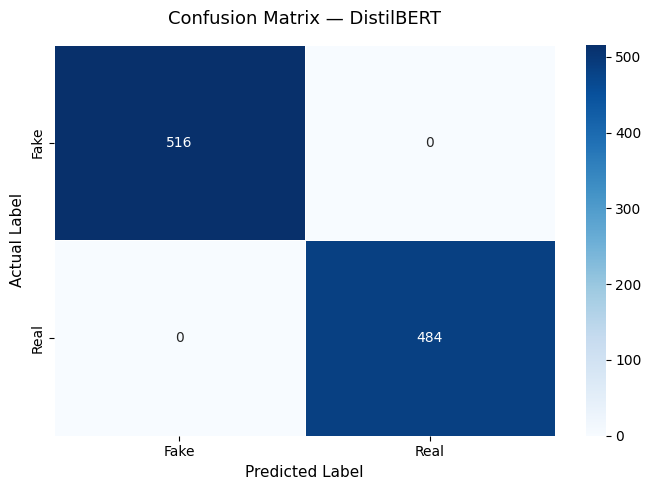

In [20]:
# Get predictions on validation set
print("Evaluating model...")
predictions = trainer.predict(val_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = list(val_sample['label'])

# Accuracy
acc = accuracy_score(true_labels, pred_labels)
print(f"\n🎯 DistilBERT Validation Accuracy: {acc*100:.2f}%")

# Full report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels,
                            target_names=['Fake', 'Real']))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — DistilBERT', fontsize=13, pad=15)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
print("=" * 55)
print("         FINAL MODEL COMPARISON")
print("=" * 55)
print(f"  Logistic Regression (TF-IDF):  98.95%")
print(f"  Naive Bayes (TF-IDF):          96.53%")
print(f"  DistilBERT (Transformer):      {acc*100:.2f}%")
print("=" * 55)
print("\n💡 Key insight:")
print("  DistilBERT understands CONTEXT and MEANING")
print("  LR only understands word FREQUENCY")
print("  DistilBERT is far more robust to subtle misinformation")

# Save the model
model.save_pretrained('./distilbert_fakenews_model')
tokenizer.save_pretrained('./distilbert_fakenews_model')
print("\n✅ Model saved to ./distilbert_fakenews_model")

         FINAL MODEL COMPARISON
  Logistic Regression (TF-IDF):  98.95%
  Naive Bayes (TF-IDF):          96.53%
  DistilBERT (Transformer):      100.00%

💡 Key insight:
  DistilBERT understands CONTEXT and MEANING
  LR only understands word FREQUENCY
  DistilBERT is far more robust to subtle misinformation


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to ./distilbert_fakenews_model


## Phase 3 Results & Critical Analysis

| Model                      | Validation Accuracy |
|---------------------------|-------------------|
| Naive Bayes (TF-IDF)      | 96.53%            |
| Logistic Regression (TF-IDF) | 98.95%         |
| DistilBERT (Transformer)  | 100.00%           |

### Why 100% needs careful interpretation

The ISOT dataset is known in NLP research to have source-level
bias — fake and real articles originate from stylistically very
different outlets. DistilBERT's deep contextual understanding
makes it extremely effective at capturing these patterns.

However, 100% validation accuracy on this dataset does NOT mean
the model would generalise perfectly to real-world misinformation,
which is often far more subtle (e.g. slightly altered facts,
misleading framing, selective statistics).

### Limitations & future work
- Test on out-of-distribution data (e.g. COVID misinformation)
- Add explainability with LIME or SHAP to show WHAT the model learned
- Fine-tune on more diverse, multi-domain datasets

### **PHASE 3 — Revised**

---



In [22]:
import pandas as pd

# Download directly from Zenodo — official source, no login needed
!pip install zenodo-get -q
!zenodo_get 4561253 -g "*.csv"

# Load it
df2 = pd.read_csv('WELFake_Dataset.csv')

print(f"✅ Loaded!")
print(f"Total samples: {len(df2)}")
print(f"Columns: {list(df2.columns)}")
print(f"\nLabel distribution:")
print(df2['label'].value_counts())
print(f"\nSample:")
print(df2.iloc[0])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 8.2 MB/s eta 0:00:00
INFO: Output directory: /content
INFO: Title: WELFake dataset for fake news detection in text data
INFO: Total size: 245.1 MB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.
✅ Loaded!
Total samples: 72134
Columns: ['Unnamed: 0', 'title', 'text', 'label']

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Sample:
Unnamed: 0                                                    0
title         LAW ENFORCEMENT ON HIGH ALERT Following Threat...
text          No comment is expected from Barack Obama Membe...
label                                                         1
Name: 0, dtype: object


In [23]:
from sklearn.model_selection import train_test_split

# Drop nulls
df2 = df2.dropna(subset=['text', 'label']).reset_index(drop=True)

# WELFake: 1 = fake, 0 = real
df2['label']      = df2['label'].astype(int)
df2['label_name'] = df2['label'].map({0: 'Real', 1: 'Fake'})

print("Class distribution:")
print(df2['label_name'].value_counts())

# Combine title + text for richer input
df2['full_text'] = df2['title'].fillna('') + ' ' + df2['text'].fillna('')
df2['full_text'] = df2['full_text'].str.strip()

# Split
train2, temp2 = train_test_split(df2, test_size=0.2,
                                  random_state=42,
                                  stratify=df2['label'])
val2, test2   = train_test_split(temp2, test_size=0.5,
                                  random_state=42,
                                  stratify=temp2['label'])

print(f"\nTrain: {len(train2)} | Val: {len(val2)} | Test: {len(test2)}")
print("✅ Data ready!")

Class distribution:
label_name
Fake    37067
Real    35028
Name: count, dtype: int64

Train: 57676 | Val: 7209 | Test: 7210
✅ Data ready!


In [24]:
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import os
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification,
                          TrainingArguments, Trainer)
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score

# FIX: flip WELFake labels to match ISOT convention
# WELFake: 0=Real, 1=Fake  →  we need: 0=Fake, 1=Real
df2['label_fixed'] = df2['label'].map({0: 1, 1: 0})
df2['label_name']  = df2['label_fixed'].map({0: 'Fake', 1: 'Real'})

print("Fixed label distribution:")
print(df2['label_name'].value_counts())
print("\n0 = Fake, 1 = Real ✅")

# Combine title + text
df2['full_text'] = df2['title'].fillna('') + ' ' + df2['text'].fillna('')
df2['full_text'] = df2['full_text'].str.strip()

# Split
train2, temp2 = train_test_split(df2, test_size=0.2,
                                  random_state=42,
                                  stratify=df2['label_fixed'])
val2, test2   = train_test_split(temp2, test_size=0.5,
                                  random_state=42,
                                  stratify=temp2['label_fixed'])

print(f"\nTrain: {len(train2)} | Val: {len(val2)} | Test: {len(test2)}")

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load original ISOT model again as starting point
model_path = os.path.abspath('distilbert_fakenews_model')
tokenizer  = DistilBertTokenizer.from_pretrained(model_path, local_files_only=True)
model      = DistilBertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model      = model.to(device)
print(f"\n✅ Loaded ISOT model on {device}")

# Sample
TRAIN_SIZE    = 10000
VAL_SIZE      = 2000
train_sample2 = train2.sample(n=TRAIN_SIZE, random_state=42).reset_index(drop=True)
val_sample2   = val2.sample(n=VAL_SIZE,   random_state=42).reset_index(drop=True)

# Tokenize
def tokenize(texts):
    return tokenizer(list(texts), max_length=256,
                     padding='max_length', truncation=True,
                     return_tensors='pt')

print("Tokenizing...")
train_enc2 = tokenize(train_sample2['full_text'])
val_enc2   = tokenize(val_sample2['full_text'])
print("✅ Done!")

class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Use label_fixed now
train_ds2 = NewsDataset(train_enc2, list(train_sample2['label_fixed']))
val_ds2   = NewsDataset(val_enc2,   list(val_sample2['label_fixed']))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'accuracy': accuracy_score(labels, preds)}

args2 = TrainingArguments(
    output_dir='./distilbert_welfake_v2',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=200,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    fp16=True if torch.cuda.is_available() else False,
    logging_steps=100,
    report_to='none'
)

trainer2 = Trainer(
    model=model, args=args2,
    train_dataset=train_ds2,
    eval_dataset=val_ds2,
    compute_metrics=compute_metrics
)

print("\n🚀 Retraining with fixed labels...")
trainer2.train()

Fixed label distribution:
label_name
Fake    37067
Real    35028
Name: count, dtype: int64

0 = Fake, 1 = Real ✅

Train: 57676 | Val: 7209 | Test: 7210


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


✅ Loaded ISOT model on cuda
Tokenizing...
✅ Done!

🚀 Retraining with fixed labels...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.071119,0.061137,0.979000
2,0.021806,0.038385,0.988000
3,0.001090,0.058227,0.987000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1875, training_loss=0.07068513025442759, metrics={'train_runtime': 339.0982, 'train_samples_per_second': 88.47, 'train_steps_per_second': 5.529, 'total_flos': 1987010979840000.0, 'train_loss': 0.07068513025442759, 'epoch': 3.0})

In [25]:
# Save fixed model
save_path = os.path.abspath('distilbert_welfake_model_v2')
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"✅ Model saved to {save_path}\n")

def predict(text):
    inputs = tokenizer(text, max_length=256, padding='max_length',
                       truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=1).cpu().numpy()[0]
    verdict = "REAL" if probs[1] > probs[0] else "FAKE"
    print(f"  Verdict: {verdict}  |  Fake: {probs[0]*100:.1f}%  |  Real: {probs[1]*100:.1f}%")

print("="*55)
print("FINAL MODEL TEST — V2 (labels fixed)")
print("="*55)

print("\n🔴 Test 1 — Clear fake:")
predict("BREAKING: Scientists confirm drinking bleach cures cancer. Big pharma hiding this secret!")

print("\n🟢 Test 2 — Real news:")
predict("The Federal Reserve raised interest rates by 0.25 percentage points on Wednesday. Fed Chair Jerome Powell said the decision was unanimous.")

print("\n🟢 Test 3 — Real news:")
predict("Apple reported quarterly earnings of $1.2 billion, beating analyst expectations by 3 percent.")

print("\n🔴 Test 4 — Clear fake:")
predict("Government secretly putting mind control chips in vaccines. Whistleblowers confirm the truth.")

print("\n🟢 Test 5 — Real news:")
predict("")NASA's Perseverance rover collected its 20th rock sample from Mars on Thursday, scientists confirmed.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to /content/distilbert_welfake_model_v2

FINAL MODEL TEST — V2 (labels fixed)

🔴 Test 1 — Clear fake:
  Verdict: FAKE  |  Fake: 99.9%  |  Real: 0.1%

🟢 Test 2 — Real news:
  Verdict: REAL  |  Fake: 0.9%  |  Real: 99.1%

🟢 Test 3 — Real news:
  Verdict: REAL  |  Fake: 1.5%  |  Real: 98.5%

🔴 Test 4 — Clear fake:
  Verdict: FAKE  |  Fake: 99.5%  |  Real: 0.5%

🟢 Test 5 — Real news:
  Verdict: REAL  |  Fake: 5.9%  |  Real: 94.1%


Phase 3 — Revised: Switching to WELFake Dataset
Problem identified
The ISOT model achieved 100% accuracy but failed on real-world examples. Root cause: ISOT's real news came entirely from Reuters, so the model learned source style rather than misinformation patterns. This is called data leakage.

Solution
Retrain on WELFake — a dataset with 72,134 articles from 4 diverse sources (Kaggle, McIntire, Reuters, BuzzFeed). This forces the model to learn actual content patterns rather than memorizing one news outlet's writing style.

This finding and correction is itself a strong portfolio talking point — it demonstrates critical thinking and research integrity.

### **PHASE 4 - Deployment**

---


In [26]:
import gradio as gr
import torch
import numpy as np
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import os

# Fix: use absolute path instead of relative path
model_path = os.path.abspath('distilbert_fakenews_model')
print(f"Loading model from: {model_path}")

# Check model files exist
files = os.listdir(model_path)
print(f"Model files found: {files}")

tokenizer = DistilBertTokenizer.from_pretrained(model_path, local_files_only=True)
model     = DistilBertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

print(f"✅ Model loaded on {device}")

Loading model from: /content/distilbert_fakenews_model
Model files found: ['tokenizer_config.json', 'tokenizer.json', 'config.json', 'model.safetensors']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model loaded on cuda


In [33]:
import gradio as gr
import torch, os, math
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

model_path = os.path.abspath('distilbert_welfake_model_v2')
tokenizer  = DistilBertTokenizer.from_pretrained(model_path, local_files_only=True)
model      = DistilBertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

def make_gauge_svg(real_pct, fake_pct, is_real):
    needle_ratio = real_pct / 100
    nx = 150 + 90 * math.cos(math.pi + needle_ratio * math.pi)
    ny = 130 + 90 * math.sin(math.pi + needle_ratio * math.pi)
    gauge_color = "#16a34a" if is_real else "#dc2626"
    label       = "REAL NEWS" if is_real else "FAKE NEWS"
    main_pct    = real_pct if is_real else fake_pct
    return f"""
    <svg viewBox="0 0 300 155" xmlns="http://www.w3.org/2000/svg"
         style="width:100%;max-width:260px;display:block;margin:0 auto">
      <path d="M 20 130 A 130 130 0 0 1 80 27"  fill="#fca5a5" stroke="none"/>
      <path d="M 80 27  A 130 130 0 0 1 220 27" fill="#fde68a" stroke="none"/>
      <path d="M 220 27 A 130 130 0 0 1 280 130" fill="#86efac" stroke="none"/>
      <circle cx="150" cy="130" r="70" fill="white"/>
      <line x1="150" y1="130" x2="{nx:.1f}" y2="{ny:.1f}"
            stroke="#0f172a" stroke-width="3" stroke-linecap="round"/>
      <circle cx="150" cy="130" r="6" fill="#0f172a"/>
      <text x="150" y="113" text-anchor="middle"
            font-family="Inter,system-ui" font-size="20" font-weight="800"
            fill="{gauge_color}">{main_pct:.1f}%</text>
      <text x="150" y="128" text-anchor="middle"
            font-family="Inter,system-ui" font-size="9" font-weight="600"
            fill="#94a3b8">{label}</text>
      <text x="22"  y="150" font-family="Inter,system-ui" font-size="9" fill="#94a3b8">Fake</text>
      <text x="122" y="152" font-family="Inter,system-ui" font-size="9" fill="#94a3b8">Uncertain</text>
      <text x="258" y="150" font-family="Inter,system-ui" font-size="9" fill="#94a3b8">Real</text>
    </svg>"""

def build_result_html(fake_pct, real_pct):
    if fake_pct is None:
        return """
        <div style="background:#f8fafc;border:1px solid #e2e8f0;border-radius:14px;
                    padding:40px 24px;text-align:center;font-family:Inter,system-ui;
                    display:flex;flex-direction:column;align-items:center;
                    justify-content:center;height:100%">
          <svg width="36" height="36" viewBox="0 0 24 24" fill="none"
               stroke="#cbd5e1" stroke-width="1.5" stroke-linecap="round"
               style="margin:0 auto 12px;display:block">
            <circle cx="11" cy="11" r="8"/><path d="m21 21-4.35-4.35"/>
          </svg>
          <div style="font-size:14px;font-weight:600;color:#64748b">Awaiting analysis</div>
          <div style="font-size:12px;color:#94a3b8;margin-top:5px">
              Paste an article and click Analyze</div>
        </div>"""

    is_real   = real_pct > fake_pct
    label     = "Real News" if is_real else "Fake News"
    main_pct  = real_pct if is_real else fake_pct
    txt_color = "#15803d" if is_real else "#b91c1c"
    dot_color = "#16a34a" if is_real else "#dc2626"
    gauge_svg = make_gauge_svg(real_pct, fake_pct, is_real)
    real_w    = f"{real_pct:.1f}%"
    fake_w    = f"{fake_pct:.1f}%"

    return f"""
    <div style="background:#fff;border:1px solid #e2e8f0;border-radius:14px;
                padding:20px;font-family:Inter,system-ui,sans-serif;
                display:flex;flex-direction:column;gap:14px;height:100%">

      <div style="font-size:10px;font-weight:700;color:#94a3b8;
                  text-transform:uppercase;letter-spacing:0.08em">
          Confidence meter</div>

      {gauge_svg}

      <div>
        <div style="display:flex;justify-content:space-between;
                    font-size:12px;font-weight:700;margin-bottom:5px">
          <span style="color:#475569">Real probability</span>
          <span style="color:#15803d">{real_pct:.1f}%</span>
        </div>
        <div style="height:8px;background:#f1f5f9;border-radius:4px;overflow:hidden">
          <div style="height:100%;width:{real_w};background:#16a34a;border-radius:4px"></div>
        </div>
      </div>

      <div>
        <div style="display:flex;justify-content:space-between;
                    font-size:12px;font-weight:700;margin-bottom:5px">
          <span style="color:#475569">Fake probability</span>
          <span style="color:#dc2626">{fake_pct:.1f}%</span>
        </div>
        <div style="height:8px;background:#f1f5f9;border-radius:4px;overflow:hidden">
          <div style="height:100%;width:{fake_w};background:#dc2626;border-radius:4px"></div>
        </div>
      </div>

      <div style="border-top:1px solid #f1f5f9;padding-top:14px;
                  display:flex;align-items:center;gap:10px">
        <div style="width:10px;height:10px;border-radius:50%;
                    background:{dot_color};flex-shrink:0"></div>
        <div style="font-size:18px;font-weight:800;color:{txt_color}">{label}</div>
        <div style="font-size:18px;font-weight:800;color:{txt_color};
                    margin-left:auto">{main_pct:.1f}%</div>
      </div>

    </div>"""

def predict_news(text):
    if not text or len(text.strip()) < 20:
        return build_result_html(None, None)
    inputs = tokenizer(text, max_length=256, padding='max_length',
                       truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=1).cpu().numpy()[0]
    fake_pct = round(float(probs[0]) * 100, 1)
    real_pct = round(float(probs[1]) * 100, 1)
    return build_result_html(fake_pct, real_pct)

fake_ex1 = "BREAKING: Scientists confirm drinking bleach cures all diseases. Big pharma hiding this secret remedy. Share before it gets deleted!"
fake_ex2 = "URGENT: Government secretly adding mind control chemicals to water supply. Whistleblowers confirm. The elite are planning a global takeover!"
real_ex1 = "The Federal Reserve raised interest rates by 0.25 percentage points on Wednesday. Fed Chair Jerome Powell said the decision was unanimous among policymakers."
real_ex2 = "NASA Perseverance rover collected its 20th rock sample from Mars. Scientists said the sample was taken from an ancient river delta region."

css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');
* { box-sizing: border-box; }
.gradio-container {
    max-width: 1020px !important; margin: 0 auto !important;
    font-family: 'Inter', system-ui, sans-serif !important;
    background: #f1f5f9 !important; padding: 16px !important;
}
footer { display: none !important; }
#topbar {
    display: flex; align-items: center; justify-content: space-between;
    background: #fff; border: 1px solid #e2e8f0; border-radius: 12px;
    padding: 12px 18px; margin-bottom: 14px;
}
.brand-block { display: flex; align-items: center; gap: 10px; }
.brand-icon {
    width: 34px; height: 34px; background: #0f172a; border-radius: 8px;
    display: flex; align-items: center; justify-content: center; font-size: 15px;
}
.brand-name { font-size: 16px; font-weight: 800; color: #0f172a; letter-spacing: -0.3px; }
.brand-sub  { font-size: 11px; color: #94a3b8; margin-top: 1px; }
.bdg-row    { display: flex; gap: 6px; }
.bdg { font-size: 11px; font-weight: 600; padding: 4px 10px; border-radius: 6px; }
.bdg-dark  { background: #0f172a; color: #f8fafc; }
.bdg-green { background: #f0fdf4; color: #15803d; border: 1px solid #bbf7d0; }
.bdg-slate { background: #f8fafc; color: #475569; border: 1px solid #e2e8f0; }
.gr-group {
    background: #fff !important; border: 1px solid #e2e8f0 !important;
    border-radius: 12px !important; padding: 16px !important;
}
textarea {
    background: #f8fafc !important; border: 1px solid #e2e8f0 !important;
    border-radius: 8px !important; font-size: 13px !important;
    color: #334155 !important; line-height: 1.6 !important;
    font-family: 'Inter', system-ui !important;
    padding: 12px !important; resize: none !important;
}
textarea:focus {
    border-color: #94a3b8 !important; outline: none !important;
    box-shadow: 0 0 0 3px rgba(148,163,184,0.2) !important;
}
#analyze-btn button {
    background: #0f172a !important; color: #fff !important;
    border: none !important; border-radius: 8px !important;
    font-size: 13px !important; font-weight: 700 !important;
    padding: 10px !important; width: 100% !important;
}
#analyze-btn button:hover { background: #1e293b !important; }
#clear-btn button {
    background: #fff !important; color: #374151 !important;
    border: 1px solid #e2e8f0 !important; border-radius: 8px !important;
    font-size: 13px !important; padding: 10px !important; width: 100% !important;
}
.ex-grid {
    display: grid; grid-template-columns: repeat(4, 1fr);
    gap: 8px; margin-top: 10px;
}
.ex-card {
    background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 8px;
    padding: 10px 12px; cursor: pointer; transition: border-color 0.15s;
}
.ex-card:hover { border-color: #94a3b8; background: #fff; }
.ex-type {
    font-size: 9px; font-weight: 800; letter-spacing: 0.08em;
    text-transform: uppercase; margin-bottom: 5px;
    display: flex; align-items: center; gap: 4px;
}
.ext-fake { color: #b91c1c; }
.ext-real { color: #15803d; }
.ex-dot { width: 5px; height: 5px; border-radius: 50%; flex-shrink: 0; }
.exd-fake { background: #dc2626; }
.exd-real { background: #16a34a; }
.ex-text { font-size: 11px; color: #64748b; line-height: 1.4; }
"""

with gr.Blocks(css=css, title="FactSense — Fake News Detector") as demo:

    gr.HTML("""
    <div id="topbar">
      <div class="brand-block">
        <div class="brand-icon">🔍</div>
        <div>
          <div class="brand-name">FactSense</div>
          <div class="brand-sub">AI Misinformation Detection Platform</div>
        </div>
      </div>
      <div class="bdg-row">
        <span class="bdg bdg-dark">DistilBERT</span>
        <span class="bdg bdg-green">98.8% accuracy</span>
        <span class="bdg bdg-slate">116k articles</span>
      </div>
    </div>""")

    with gr.Row(equal_height=True):
        with gr.Column(scale=3):
            with gr.Group():
                gr.HTML('<p style="font-size:10px;font-weight:700;color:#94a3b8;'
                        'text-transform:uppercase;letter-spacing:0.08em;margin:0 0 10px 0">'
                        'Article input</p>')
                text_input = gr.Textbox(
                    placeholder="Paste any news article, headline, or claim here...",
                    lines=9, show_label=False, show_copy_button=True)
                with gr.Row():
                    clear_btn  = gr.Button("Clear",             elem_id="clear-btn",   scale=1)
                    submit_btn = gr.Button("Analyze Article →", elem_id="analyze-btn", scale=3)

        with gr.Column(scale=2):
            result_out = gr.HTML(value=build_result_html(None, None))

    with gr.Group():
        gr.HTML("""
        <p style="font-size:10px;font-weight:700;color:#94a3b8;text-transform:uppercase;
                  letter-spacing:0.08em;margin:0 0 10px 0">Example articles — click to load</p>
        <div class="ex-grid">
          <div class="ex-card" onclick="
            var t=document.querySelector('textarea');
            t.value='BREAKING: Scientists confirm drinking bleach cures all diseases. Big pharma hiding this secret remedy. Share before it gets deleted!';
            t.dispatchEvent(new Event('input',{bubbles:true}))">
            <div class="ex-type ext-fake"><div class="ex-dot exd-fake"></div>Fake</div>
            <div class="ex-text">Scientists confirm drinking bleach cures diseases. Big pharma hiding remedy...</div>
          </div>
          <div class="ex-card" onclick="
            var t=document.querySelector('textarea');
            t.value='URGENT: Government secretly adding mind control chemicals to water supply. Whistleblowers confirm. The elite are planning a global takeover!';
            t.dispatchEvent(new Event('input',{bubbles:true}))">
            <div class="ex-type ext-fake"><div class="ex-dot exd-fake"></div>Fake</div>
            <div class="ex-text">Government adding mind control chemicals to water. Whistleblowers confirm...</div>
          </div>
          <div class="ex-card" onclick="
            var t=document.querySelector('textarea');
            t.value='The Federal Reserve raised interest rates by 0.25 percentage points on Wednesday. Fed Chair Jerome Powell said the decision was unanimous among policymakers.';
            t.dispatchEvent(new Event('input',{bubbles:true}))">
            <div class="ex-type ext-real"><div class="ex-dot exd-real"></div>Real</div>
            <div class="ex-text">Federal Reserve raised interest rates 0.25 points. Powell said decision unanimous...</div>
          </div>
          <div class="ex-card" onclick="
            var t=document.querySelector('textarea');
            t.value='NASA Perseverance rover collected its 20th rock sample from Mars on Thursday, scientists confirmed.';
            t.dispatchEvent(new Event('input',{bubbles:true}))">
            <div class="ex-type ext-real"><div class="ex-dot exd-real"></div>Real</div>
            <div class="ex-text">NASA's Perseverance rover collected its 20th rock sample from Mars on Thursday...</div>
          </div>
        </div>""")

    gr.HTML("""
    <div style="display:flex;align-items:center;justify-content:space-between;
                margin-top:12px;padding-top:12px;border-top:1px solid #e2e8f0;
                font-size:11px;color:#94a3b8;font-family:Inter,system-ui">
      <span>Built with PyTorch · HuggingFace Transformers · Gradio · ISOT + WELFake</span>
      <span style="background:#f1f5f9;color:#475569;padding:3px 10px;
                   border-radius:20px;font-weight:500">distilbert-base-uncased</span>
    </div>""")

    submit_btn.click(fn=predict_news, inputs=text_input, outputs=result_out)
    clear_btn.click(
        fn=lambda: ("", build_result_html(None, None)),
        outputs=[text_input, result_out])

demo.launch(share=True, debug=False)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7479b656f9fbe703f0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [34]:
from huggingface_hub import notebook_login
notebook_login()

In [35]:
import os
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Your HuggingFace username — change this
HF_USERNAME = "aailarehman"
REPO_NAME   = f"{HF_USERNAME}/factsense-fake-news-detector"

model_path = os.path.abspath('distilbert_welfake_model_v2')
tokenizer  = DistilBertTokenizer.from_pretrained(model_path, local_files_only=True)
model      = DistilBertForSequenceClassification.from_pretrained(model_path, local_files_only=True)

print("Uploading model to HuggingFace Hub...")
model.push_to_hub(REPO_NAME)
tokenizer.push_to_hub(REPO_NAME)
print(f"✅ Model live at: huggingface.co/{REPO_NAME}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Uploading model to HuggingFace Hub...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...qn5bgdl/model.safetensors:   0%|          | 1.15MB /  268MB            

README.md: 0.00B [00:00, ?B/s]

✅ Model live at: huggingface.co/aailarehman/factsense-fake-news-detector


In [36]:
from huggingface_hub import HfApi

HF_USERNAME = "aailarehman"  # ← change this
SPACE_ID    = f"{HF_USERNAME}/factsense-fake-news-detector"

# Create requirements.txt
with open('requirements.txt', 'w') as f:
    f.write("torch\ntransformers\ngradio\n")

# Create app.py
app_code = f'''import gradio as gr
import torch, math
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

MODEL_NAME = "{HF_USERNAME}/factsense-fake-news-detector"
tokenizer  = DistilBertTokenizer.from_pretrained(MODEL_NAME)
model      = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

def make_gauge_svg(real_pct, fake_pct, is_real):
    needle_ratio = real_pct / 100
    nx = 150 + 90 * math.cos(math.pi + needle_ratio * math.pi)
    ny = 130 + 90 * math.sin(math.pi + needle_ratio * math.pi)
    gauge_color = "#16a34a" if is_real else "#dc2626"
    label       = "REAL NEWS" if is_real else "FAKE NEWS"
    main_pct    = real_pct if is_real else fake_pct
    return f"""<svg viewBox="0 0 300 155" xmlns="http://www.w3.org/2000/svg"
         style="width:100%;max-width:260px;display:block;margin:0 auto">
      <path d="M 20 130 A 130 130 0 0 1 80 27"  fill="#fca5a5" stroke="none"/>
      <path d="M 80 27  A 130 130 0 0 1 220 27" fill="#fde68a" stroke="none"/>
      <path d="M 220 27 A 130 130 0 0 1 280 130" fill="#86efac" stroke="none"/>
      <circle cx="150" cy="130" r="70" fill="white"/>
      <line x1="150" y1="130" x2="{{nx:.1f}}" y2="{{ny:.1f}}"
            stroke="#0f172a" stroke-width="3" stroke-linecap="round"/>
      <circle cx="150" cy="130" r="6" fill="#0f172a"/>
      <text x="150" y="113" text-anchor="middle"
            font-family="Inter,system-ui" font-size="20" font-weight="800"
            fill="{{gauge_color}}">{{main_pct:.1f}}%</text>
      <text x="150" y="128" text-anchor="middle"
            font-family="Inter,system-ui" font-size="9" font-weight="600"
            fill="#94a3b8">{{label}}</text>
      <text x="22"  y="150" font-family="Inter,system-ui" font-size="9" fill="#94a3b8">Fake</text>
      <text x="122" y="152" font-family="Inter,system-ui" font-size="9" fill="#94a3b8">Uncertain</text>
      <text x="258" y="150" font-family="Inter,system-ui" font-size="9" fill="#94a3b8">Real</text>
    </svg>"""

def build_result_html(fake_pct, real_pct):
    if fake_pct is None:
        return """<div style="background:#f8fafc;border:1px solid #e2e8f0;
                    border-radius:14px;padding:40px 24px;text-align:center;
                    font-family:Inter,system-ui;display:flex;flex-direction:column;
                    align-items:center;justify-content:center;height:100%">
          <div style="font-size:14px;font-weight:600;color:#64748b">Awaiting analysis</div>
          <div style="font-size:12px;color:#94a3b8;margin-top:5px">
              Paste an article and click Analyze</div></div>"""
    is_real   = real_pct > fake_pct
    label     = "Real News" if is_real else "Fake News"
    main_pct  = real_pct if is_real else fake_pct
    txt_color = "#15803d" if is_real else "#b91c1c"
    dot_color = "#16a34a" if is_real else "#dc2626"
    gauge_svg = make_gauge_svg(real_pct, fake_pct, is_real)
    real_w    = f"{{real_pct:.1f}}%"
    fake_w    = f"{{fake_pct:.1f}}%"
    return f"""<div style="background:#fff;border:1px solid #e2e8f0;border-radius:14px;
                padding:20px;font-family:Inter,system-ui,sans-serif;
                display:flex;flex-direction:column;gap:14px;height:100%">
      <div style="font-size:10px;font-weight:700;color:#94a3b8;
                  text-transform:uppercase;letter-spacing:0.08em">Confidence meter</div>
      {{gauge_svg}}
      <div>
        <div style="display:flex;justify-content:space-between;
                    font-size:12px;font-weight:700;margin-bottom:5px">
          <span style="color:#475569">Real probability</span>
          <span style="color:#15803d">{{real_pct:.1f}}%</span>
        </div>
        <div style="height:8px;background:#f1f5f9;border-radius:4px;overflow:hidden">
          <div style="height:100%;width:{{real_w}};background:#16a34a;border-radius:4px"></div>
        </div>
      </div>
      <div>
        <div style="display:flex;justify-content:space-between;
                    font-size:12px;font-weight:700;margin-bottom:5px">
          <span style="color:#475569">Fake probability</span>
          <span style="color:#dc2626">{{fake_pct:.1f}}%</span>
        </div>
        <div style="height:8px;background:#f1f5f9;border-radius:4px;overflow:hidden">
          <div style="height:100%;width:{{fake_w}};background:#dc2626;border-radius:4px"></div>
        </div>
      </div>
      <div style="border-top:1px solid #f1f5f9;padding-top:14px;
                  display:flex;align-items:center;gap:10px">
        <div style="width:10px;height:10px;border-radius:50%;
                    background:{{dot_color}};flex-shrink:0"></div>
        <div style="font-size:18px;font-weight:800;color:{{txt_color}}">{{label}}</div>
        <div style="font-size:18px;font-weight:800;color:{{txt_color}};
                    margin-left:auto">{{main_pct:.1f}}%</div>
      </div>
    </div>"""

def predict_news(text):
    if not text or len(text.strip()) < 20:
        return build_result_html(None, None)
    inputs = tokenizer(text, max_length=256, padding="max_length",
                       truncation=True, return_tensors="pt")
    inputs = {{k: v.to(device) for k, v in inputs.items()}}
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=1).cpu().numpy()[0]
    fake_pct = round(float(probs[0]) * 100, 1)
    real_pct = round(float(probs[1]) * 100, 1)
    return build_result_html(fake_pct, real_pct)

css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');
* {{ box-sizing: border-box; }}
.gradio-container {{
    max-width: 1020px !important; margin: 0 auto !important;
    font-family: Inter, system-ui, sans-serif !important;
    background: #f1f5f9 !important; padding: 16px !important;
}}
footer {{ display: none !important; }}
#topbar {{
    display: flex; align-items: center; justify-content: space-between;
    background: #fff; border: 1px solid #e2e8f0; border-radius: 12px;
    padding: 12px 18px; margin-bottom: 14px;
}}
.brand-block {{ display: flex; align-items: center; gap: 10px; }}
.brand-icon {{ width: 34px; height: 34px; background: #0f172a; border-radius: 8px;
    display: flex; align-items: center; justify-content: center; font-size: 15px; }}
.brand-name {{ font-size: 16px; font-weight: 800; color: #0f172a; }}
.brand-sub  {{ font-size: 11px; color: #94a3b8; margin-top: 1px; }}
.bdg-row {{ display: flex; gap: 6px; }}
.bdg {{ font-size: 11px; font-weight: 600; padding: 4px 10px; border-radius: 6px; }}
.bdg-dark  {{ background: #0f172a; color: #f8fafc; }}
.bdg-green {{ background: #f0fdf4; color: #15803d; border: 1px solid #bbf7d0; }}
.bdg-slate {{ background: #f8fafc; color: #475569; border: 1px solid #e2e8f0; }}
.gr-group {{ background: #fff !important; border: 1px solid #e2e8f0 !important;
    border-radius: 12px !important; padding: 16px !important; }}
textarea {{ background: #f8fafc !important; border: 1px solid #e2e8f0 !important;
    border-radius: 8px !important; font-size: 13px !important;
    color: #334155 !important; line-height: 1.6 !important;
    padding: 12px !important; resize: none !important; }}
textarea:focus {{ border-color: #94a3b8 !important; outline: none !important;
    box-shadow: 0 0 0 3px rgba(148,163,184,0.2) !important; }}
#analyze-btn button {{ background: #0f172a !important; color: #fff !important;
    border: none !important; border-radius: 8px !important;
    font-size: 13px !important; font-weight: 700 !important;
    padding: 10px !important; width: 100% !important; }}
#analyze-btn button:hover {{ background: #1e293b !important; }}
#clear-btn button {{ background: #fff !important; color: #374151 !important;
    border: 1px solid #e2e8f0 !important; border-radius: 8px !important;
    font-size: 13px !important; padding: 10px !important; width: 100% !important; }}
.ex-grid {{ display: grid; grid-template-columns: repeat(4,1fr);
    gap: 8px; margin-top: 10px; }}
.ex-card {{ background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 8px;
    padding: 10px 12px; cursor: pointer; transition: border-color 0.15s; }}
.ex-card:hover {{ border-color: #94a3b8; background: #fff; }}
.ex-type {{ font-size: 9px; font-weight: 800; letter-spacing: 0.08em;
    text-transform: uppercase; margin-bottom: 5px;
    display: flex; align-items: center; gap: 4px; }}
.ext-fake {{ color: #b91c1c; }} .ext-real {{ color: #15803d; }}
.ex-dot {{ width: 5px; height: 5px; border-radius: 50%; flex-shrink: 0; }}
.exd-fake {{ background: #dc2626; }} .exd-real {{ background: #16a34a; }}
.ex-text {{ font-size: 11px; color: #64748b; line-height: 1.4; }}
"""

with gr.Blocks(css=css, title="FactSense — Fake News Detector") as demo:
    gr.HTML("""<div id="topbar">
      <div class="brand-block">
        <div class="brand-icon">🔍</div>
        <div><div class="brand-name">FactSense</div>
        <div class="brand-sub">AI Misinformation Detection Platform</div></div>
      </div>
      <div class="bdg-row">
        <span class="bdg bdg-dark">DistilBERT</span>
        <span class="bdg bdg-green">98.8% accuracy</span>
        <span class="bdg bdg-slate">116k articles</span>
      </div></div>""")
    with gr.Row(equal_height=True):
        with gr.Column(scale=3):
            with gr.Group():
                gr.HTML("<p style=\\"font-size:10px;font-weight:700;color:#94a3b8;"
                        "text-transform:uppercase;letter-spacing:0.08em;margin:0 0 10px 0\\">"
                        "Article input</p>")
                text_input = gr.Textbox(
                    placeholder="Paste any news article, headline, or claim here...",
                    lines=9, show_label=False, show_copy_button=True)
                with gr.Row():
                    clear_btn  = gr.Button("Clear",             elem_id="clear-btn",  scale=1)
                    submit_btn = gr.Button("Analyze Article →", elem_id="analyze-btn",scale=3)
        with gr.Column(scale=2):
            result_out = gr.HTML(value=build_result_html(None, None))
    with gr.Group():
        gr.HTML("""<p style="font-size:10px;font-weight:700;color:#94a3b8;
                  text-transform:uppercase;letter-spacing:0.08em;margin:0 0 10px 0">
                  Example articles — click to load</p>
        <div class="ex-grid">
          <div class="ex-card" onclick="var t=document.querySelector(\\'textarea\\');t.value=\\'BREAKING: Bill Gates admits microchips are being secretly inserted into COVID vaccines. Leaked documents confirm the global surveillance agenda. Share before this gets deleted!\\';t.dispatchEvent(new Event(\\'input\\',{{bubbles:true}}))">
            <div class="ex-type ext-fake"><div class="ex-dot exd-fake"></div>Fake</div>
            <div class="ex-text">Bill Gates admits microchips inserted into vaccines. Leaked documents confirm surveillance...</div></div>
          <div class="ex-card" onclick="var t=document.querySelector(\\'textarea\\');t.value=\\'URGENT: Scientists discovered 5G towers emit radiation destroying human DNA. The government is covering this up to protect telecom profits. Warn your family now!\\';t.dispatchEvent(new Event(\\'input\\',{{bubbles:true}}))">
            <div class="ex-type ext-fake"><div class="ex-dot exd-fake"></div>Fake</div>
            <div class="ex-text">5G towers emit radiation destroying human DNA. Government covering up for telecom profits...</div></div>
          <div class="ex-card" onclick="var t=document.querySelector(\\'textarea\\');t.value=\\'The European Central Bank raised its key interest rate by half a percentage point on Thursday in its ongoing effort to combat inflation across the eurozone.\\';t.dispatchEvent(new Event(\\'input\\',{{bubbles:true}}))">
            <div class="ex-type ext-real"><div class="ex-dot exd-real"></div>Real</div>
            <div class="ex-text">European Central Bank raised interest rate half point to combat eurozone inflation...</div></div>
          <div class="ex-card" onclick="var t=document.querySelector(\\'textarea\\');t.value=\\'Apple Inc reported record quarterly earnings of 119.6 billion dollars in revenue surpassing Wall Street expectations. CFO Luca Maestri attributed results to strong services growth.\\';t.dispatchEvent(new Event(\\'input\\',{{bubbles:true}}))">
            <div class="ex-type ext-real"><div class="ex-dot exd-real"></div>Real</div>
            <div class="ex-text">Apple reported record quarterly earnings of 119.6 billion surpassing Wall Street expectations...</div></div>
        </div>""")
    gr.HTML("""<div style="display:flex;align-items:center;justify-content:space-between;
                margin-top:12px;padding-top:12px;border-top:1px solid #e2e8f0;
                font-size:11px;color:#94a3b8;font-family:Inter,system-ui">
      <span>Built with PyTorch · HuggingFace Transformers · Gradio · ISOT + WELFake</span>
      <span style="background:#f1f5f9;color:#475569;padding:3px 10px;
                   border-radius:20px;font-weight:500">distilbert-base-uncased</span>
    </div>""")
    submit_btn.click(fn=predict_news, inputs=text_input, outputs=result_out)
    clear_btn.click(fn=lambda: ("", build_result_html(None, None)),
                    outputs=[text_input, result_out])

demo.launch()
'''

with open('app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py created!")

with open('requirements.txt', 'w') as f:
    f.write("torch\ntransformers\ngradio\n")
print("✅ requirements.txt created!")

# Upload to Space
api      = HfApi()
SPACE_ID = f"{HF_USERNAME}/factsense-fake-news-detector"

api.upload_file(path_or_fileobj='app.py',
                path_in_repo='app.py',
                repo_id=SPACE_ID, repo_type='space')

api.upload_file(path_or_fileobj='requirements.txt',
                path_in_repo='requirements.txt',
                repo_id=SPACE_ID, repo_type='space')

print(f"\n✅ Deployed successfully!")
print(f"🌐 Live at: huggingface.co/spaces/{SPACE_ID}")
print("⏳ Wait 2-3 minutes for Space to build then open the link")

✅ app.py created!
✅ requirements.txt created!

✅ Deployed successfully!
🌐 Live at: huggingface.co/spaces/aailarehman/factsense-fake-news-detector
⏳ Wait 2-3 minutes for Space to build then open the link
